In [1]:
import pandas as pd
import numpy as np

In [2]:
D = pd.read_csv("Flourishing_Processed_Part1.csv")
print(D.shape)
D.head()

(284, 66)


,Individu,GUI,SECTEUR,TAILLE,FONCTION,ANCIENNETE,AGE,SEX,SITUFAM,NBENFANT,...,Flux4,Flux5,Flux6,Flux7,Flux8,Flux9,Flourishing_Work,Flourishing_Private,Positivity_Ratio,Emotional_Status
0,83,c7251f433fbaa,,0,,0,0,0,0,0,...,5.0,4.0,4.0,5.0,4.0,5.0,Flourishing,Flourishing,1.454545,Emotionally Languishing
1,151,c72c265502d92,,0,,0,0,0,0,0,...,6.0,4.0,5.0,5.0,5.0,5.0,Moderate,Flourishing,1.666667,Emotionally Languishing
2,177,c7356f5742de,,0,,0,0,0,0,0,...,5.0,4.0,4.0,4.0,4.0,4.0,Moderate,Flourishing,1.600000,Emotionally Languishing
3,184,c735b612f44b9,,0,,0,0,0,0,0,...,4.0,4.0,4.0,3.0,3.0,3.0,Languishing,Moderate,1.090909,Emotionally Languishing
4,190,c73665b71c,,0,,0,0,0,0,0,...,3.0,2.0,3.0,4.0,4.0,4.0,Moderate,Moderate,1.700000,Emotionally Languishing


In [3]:
candidate_cols = [
    "Flourishing_Work",
    "Flourishing_Private",
    "Emotional_Status",
    "SEX",
    "SITUFAM",
    "TAILLE",
    "NIVEAUETUDE",
    "AGE",
    "ANCIENNETE",
    "NBENFANT",
]

In [4]:
mca_base = D[candidate_cols].copy()

coded_numeric_cols = ["SEX", "SITUFAM", "TAILLE", "NIVEAUETUDE", "AGE", "ANCIENNETE", "NBENFANT"]
for col in coded_numeric_cols:
    mca_base[col] = pd.to_numeric(mca_base[col], errors="coerce")

mca_base.loc[mca_base["AGE"] == 0, "AGE"] = np.nan

mca_base.head()

,Flourishing_Work,Flourishing_Private,Emotional_Status,SEX,SITUFAM,TAILLE,NIVEAUETUDE,AGE,ANCIENNETE,NBENFANT
0,Flourishing,Flourishing,Emotionally Languishing,0,0,0,0,NaN,0,0
1,Moderate,Flourishing,Emotionally Languishing,0,0,0,0,NaN,0,0
2,Moderate,Flourishing,Emotionally Languishing,0,0,0,0,NaN,0,0
3,Languishing,Moderate,Emotionally Languishing,0,0,0,0,NaN,0,0
4,Moderate,Moderate,Emotionally Languishing,0,0,0,0,NaN,0,0


In [5]:
def label_from_code(series, prefix):
    return series.map(lambda x: np.nan if pd.isna(x) else f"{prefix}_{int(x)}")

mca_df = pd.DataFrame(index=mca_base.index)

mca_df["Flourishing_Work"] = mca_base["Flourishing_Work"].astype("string")
mca_df["Flourishing_Private"] = mca_base["Flourishing_Private"].astype("string")
mca_df["Emotional_Status"] = mca_base["Emotional_Status"].astype("string")

sex_map = {0: "female", 1: "male"}
mca_df["SEX_CAT"] = mca_base["SEX"].map(sex_map)

situfam_map = {1:"single", 2:"Separated or divorced", 3:"in a partner relationship"}
mca_df["SITUFAM"] = mca_base["SITUFAM"].map(situfam_map)

taille_map = {1: "small", 2: "medium", 3: "large", 4: "very large", 5: "huge"}
mca_df["TAILLE_CAT"] = mca_base["TAILLE"].map(taille_map)

niveauetude_map = {
    0: "unknown_or_missing",
    1: "below_high_school",
    2: "high_school",
    3: "bac_plus_2",
    4: "bachelor",
    5: "master_M1",
    6: "master_M2_or_phd",
}
mca_df["NIVEAUETUDE_CAT"] = mca_base["NIVEAUETUDE"].map(niveauetude_map)

mca_df["AGE_CAT"] = pd.cut(
    mca_base["AGE"],
    bins=[0, 29, 39, 49, np.inf],
    labels=["AGE_18_29", "AGE_30_39", "AGE_40_49", "AGE_50_PLUS"],
)

mca_df["ANCIENNETE_CAT"] = pd.cut(
    mca_base["ANCIENNETE"],
    bins=[-0.1, 2, 5, 10, np.inf],
    labels=["TENURE_0_2", "TENURE_3_5", "TENURE_6_10", "TENURE_11_PLUS"],
)

mca_df["NBENFANT_CAT"] = pd.cut(
    mca_base["NBENFANT"],
    bins=[-0.1, 0, 1, 2, np.inf],
    labels=["CHILDREN_0", "CHILDREN_1", "CHILDREN_2", "CHILDREN_3_PLUS"],
)

mca_df.head()

,Flourishing_Work,Flourishing_Private,Emotional_Status,SEX_CAT,SITUFAM,TAILLE_CAT,NIVEAUETUDE_CAT,AGE_CAT,ANCIENNETE_CAT,NBENFANT_CAT
0,Flourishing,Flourishing,Emotionally Languishing,female,NaN,NaN,unknown_or_missing,NaN,TENURE_0_2,CHILDREN_0
1,Moderate,Flourishing,Emotionally Languishing,female,NaN,NaN,unknown_or_missing,NaN,TENURE_0_2,CHILDREN_0
2,Moderate,Flourishing,Emotionally Languishing,female,NaN,NaN,unknown_or_missing,NaN,TENURE_0_2,CHILDREN_0
3,Languishing,Moderate,Emotionally Languishing,female,NaN,NaN,unknown_or_missing,NaN,TENURE_0_2,CHILDREN_0
4,Moderate,Moderate,Emotionally Languishing,female,NaN,NaN,unknown_or_missing,NaN,TENURE_0_2,CHILDREN_0


In [6]:
missing_report = pd.DataFrame({
    "n_missing": mca_df.isna().sum(),
    "pct_missing": (mca_df.isna().mean() * 100).round(2),
    "n_unique": mca_df.nunique(dropna=True),
})
missing_report

,n_missing,pct_missing,n_unique
Flourishing_Work,0,0.00,3
Flourishing_Private,0,0.00,3
Emotional_Status,0,0.00,4
SEX_CAT,0,0.00,2
SITUFAM,41,14.44,3
TAILLE_CAT,41,14.44,5
NIVEAUETUDE_CAT,0,0.00,7
AGE_CAT,39,13.73,4
ANCIENNETE_CAT,0,0.00,4
NBENFANT_CAT,0,0.00,4


In [7]:
mca_ready = mca_df.dropna().copy()

print("Shape before dropping missing values:", mca_df.shape)
print("Shape after dropping missing values:", mca_ready.shape)

mca_ready.head()

Shape before dropping missing values: (284, 10)
Shape after dropping missing values: (234, 10)


,Flourishing_Work,Flourishing_Private,Emotional_Status,SEX_CAT,SITUFAM,TAILLE_CAT,NIVEAUETUDE_CAT,AGE_CAT,ANCIENNETE_CAT,NBENFANT_CAT
30,Languishing,Flourishing,Emotionally Languishing,female,Separated or divorced,huge,high_school,AGE_50_PLUS,TENURE_11_PLUS,CHILDREN_0
33,Moderate,Moderate,Emotionally Languishing,female,in a partner relationship,medium,master_M2_or_phd,AGE_30_39,TENURE_0_2,CHILDREN_2
36,Moderate,Flourishing,Moderately Healthy,female,in a partner relationship,huge,master_M2_or_phd,AGE_30_39,TENURE_6_10,CHILDREN_1
37,Moderate,Moderate,Depressed,female,in a partner relationship,medium,bac_plus_2,AGE_30_39,TENURE_3_5,CHILDREN_0
38,Moderate,Moderate,Emotionally Languishing,female,Separated or divorced,huge,bac_plus_2,AGE_40_49,TENURE_0_2,CHILDREN_2


In [8]:
from fanalysis.mca import MCA

acm = MCA(
    row_labels=mca_ready.index,
    var_labels=mca_ready.columns
)

acm.fit(mca_ready.values)

MCA(row_labels=Index([ 30,  33,  36,  37,  38,  39,  40,  41,  42,  43,
       ...
       271, 272, 273, 274, 276, 277, 278, 279, 280, 283],
      dtype='int64', length=234),
    var_labels=Index(['Flourishing_Work', 'Flourishing_Private', 'Emotional_Status',
       'SEX_CAT', 'SITUFAM', 'TAILLE_CAT', 'NIVEAUETUDE_CAT', 'AGE_CAT',
       'ANCIENNETE_CAT', 'NBENFANT_CAT'],
      dtype='object'))

In [9]:
eig = pd.DataFrame(
    {
        "Eigenvalue": acm.eig_[0],
        "Percentage": acm.eig_[1],
        "Cumulative_Percentage": acm.eig_[2],
    },
    index=range(1, len(acm.eig_[0]) + 1)
)

eig

,Eigenvalue,Percentage,Cumulative_Percentage
1,0.247332,8.528695,8.528695
2,0.208653,7.194930,15.723625
3,0.187860,6.477927,22.201552
4,0.150150,5.177590,27.379142
5,0.140567,4.847132,32.226274
6,0.138878,4.788882,37.015156
7,0.126594,4.365318,41.380474
8,0.124811,4.303815,45.684288
9,0.118418,4.083392,49.767680
10,0.115471,3.981754,53.749435


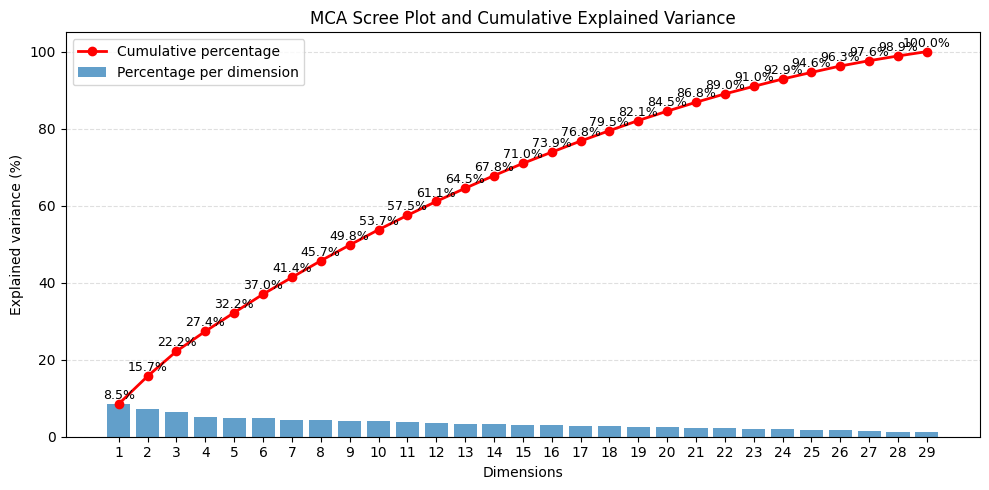

In [10]:
import matplotlib.pyplot as plt

dims = eig.index
var_pct = eig["Percentage"]
cum_pct = eig["Cumulative_Percentage"]

plt.figure(figsize=(10, 5))

plt.bar(dims, var_pct, alpha=0.7, label="Percentage per dimension")

plt.plot(dims, cum_pct, marker="o", color="red", linewidth=2, label="Cumulative percentage")

for x, y in zip(dims, cum_pct):
    plt.text(x, y + 0.5, f"{y:.1f}%", ha="center", va="bottom", fontsize=9)

plt.xlabel("Dimensions")
plt.ylabel("Explained variance (%)")
plt.title("MCA Scree Plot and Cumulative Explained Variance")
plt.xticks(dims)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

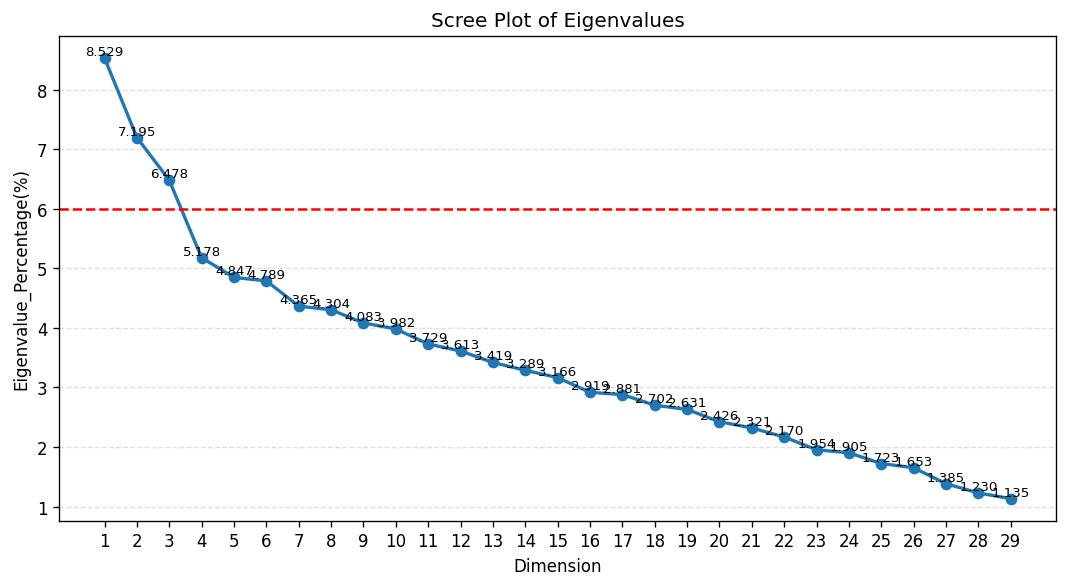

In [11]:
import matplotlib.pyplot as plt
import numpy as np

dims = eig.index.to_numpy()
eigvals = eig["Eigenvalue"].to_numpy()
eigvals_pct = eig["Percentage"].to_numpy()

plt.figure(figsize=(9, 5), dpi=120)
plt.plot(dims, eigvals_pct, marker="o", linewidth=2, color="#1f77b4")
plt.axhline(y=6, color="red", linestyle="--", linewidth=1.5, label="y = 0.13")
plt.xticks(dims)

for x, y in zip(dims, eigvals_pct):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontsize=8)

plt.xlabel("Dimension")
plt.ylabel("Eigenvalue_Percentage(%)")
plt.title("Scree Plot of Eigenvalues")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [12]:
modality_coords = pd.DataFrame(
    acm.col_coord_[:, :3],
    index=acm.col_labels_,
    columns=["Dim1", "Dim2", "Dim3"]
)

modality_coords

,Dim1,Dim2,Dim3
Flourishing_Work_Flourishing,1.365697,-0.490501,0.218480
Flourishing_Work_Languishing,-0.861046,-0.616759,-0.679575
Flourishing_Work_Moderate,-0.160297,0.407398,0.179047
Flourishing_Private_Flourishing,1.024590,-0.188499,0.122144
Flourishing_Private_Languishing,-1.320953,-1.669763,-0.745417
Flourishing_Private_Moderate,-0.396520,0.320649,0.028866
Emotional_Status_Depressed,-0.886678,-0.708860,-0.967627
Emotional_Status_Emotionally Flourishing,1.568360,-0.155244,-0.714110
Emotional_Status_Emotionally Languishing,-0.305710,0.340804,0.364500
Emotional_Status_Moderately Healthy,0.890405,-0.051716,0.286880


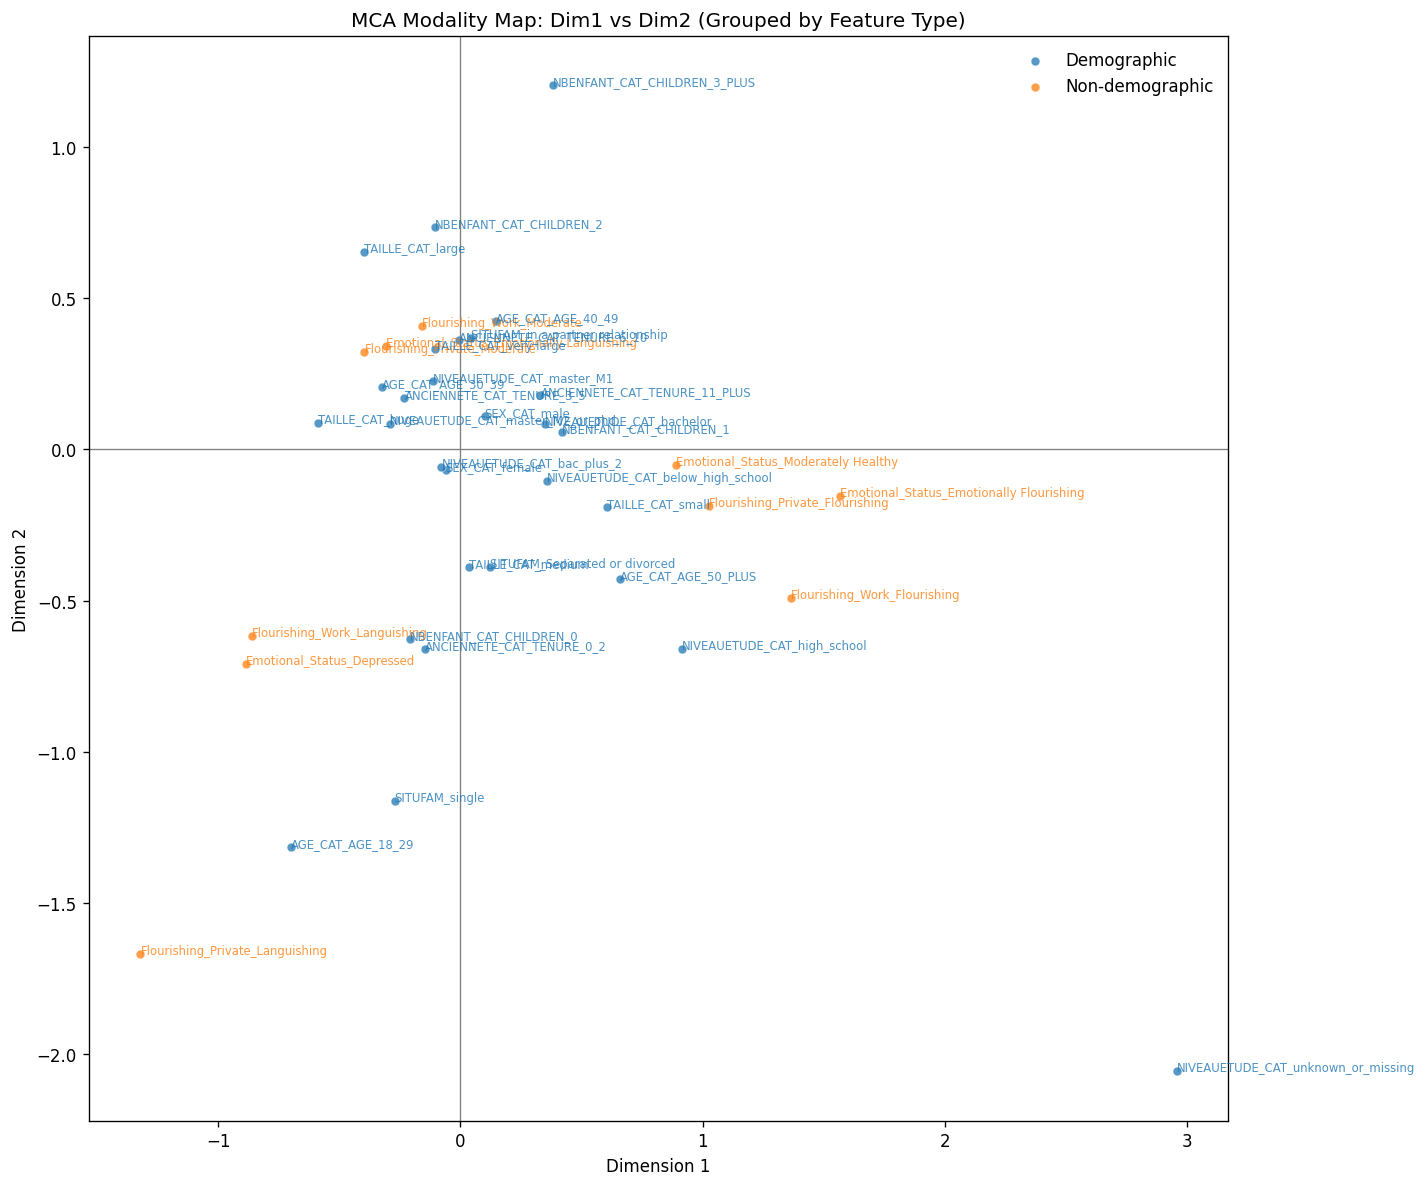

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

demographic_vars = [
    "SEX_CAT", "SITUFAM", "TAILLE_CAT", "NIVEAUETUDE_CAT",
    "AGE_CAT", "ANCIENNETE_CAT", "NBENFANT_CAT"
]
non_demographic_vars = ["Flourishing_Work", "Flourishing_Private", "Emotional_Status"]

def feature_group(label):
    s = str(label)
    if any(v in s for v in demographic_vars):
        return "Demographic"
    if any(v in s for v in non_demographic_vars):
        return "Non-demographic"
    return "Other"

coords = modality_coords[["Dim1", "Dim2"]].copy()
groups = pd.Series(coords.index, index=coords.index).map(feature_group)

colors = {
    "Demographic": "#1f77b4",
    "Non-demographic": "#ff7f0e",
    "Other": "#7f7f7f"
}

plt.figure(figsize=(12, 10), dpi=120)
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)

# 分组画点
for g in ["Demographic", "Non-demographic", "Other"]:
    m = groups == g
    if m.any():
        plt.scatter(
            coords.loc[m, "Dim1"],
            coords.loc[m, "Dim2"],
            s=28,
            alpha=0.75,
            c=colors[g],
            label=g,
            edgecolors="white",
            linewidths=0.3
        )

for label, (x, y) in coords.iterrows():
    g = groups.loc[label]
    plt.text(
        x, y, str(label),
        fontsize=7,
        color=colors[g],
        alpha=0.8
    )

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("MCA Modality Map: Dim1 vs Dim2 (Grouped by Feature Type)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


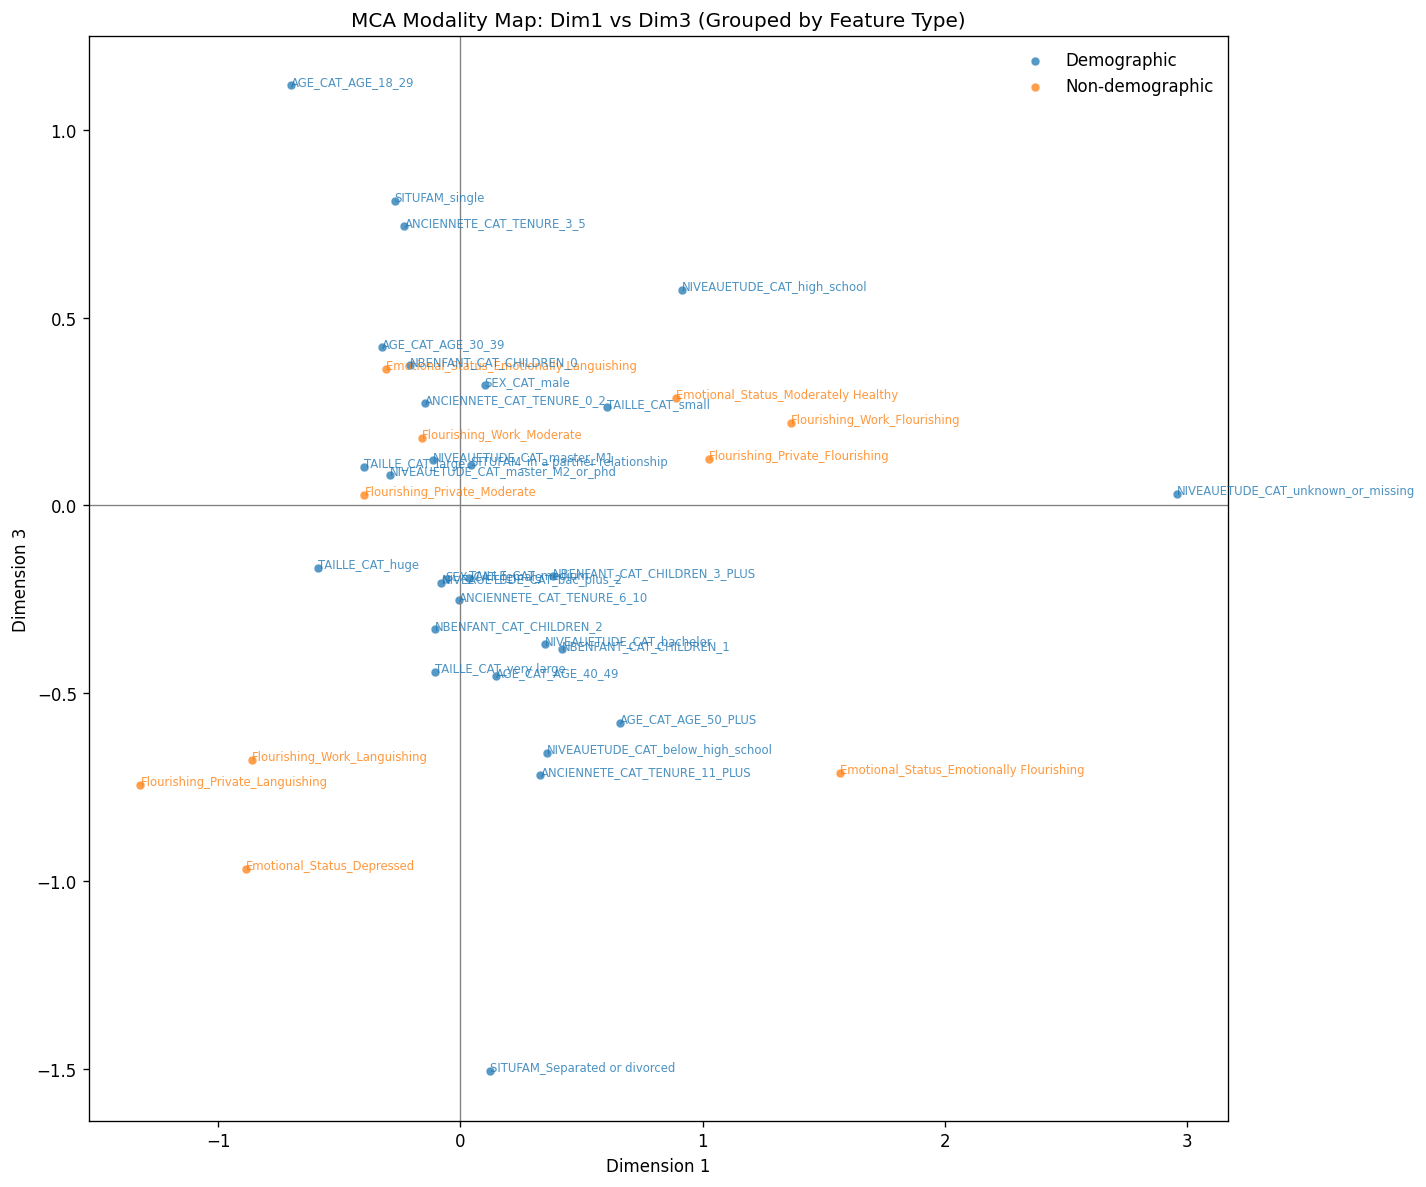

In [14]:
coords = modality_coords[["Dim1", "Dim3"]].copy()
groups = pd.Series(coords.index, index=coords.index).map(feature_group)

plt.figure(figsize=(12, 10), dpi=120)
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)

for g in ["Demographic", "Non-demographic", "Other"]:
    m = groups == g
    if m.any():
        plt.scatter(
            coords.loc[m, "Dim1"],
            coords.loc[m, "Dim3"],
            s=28,
            alpha=0.75,
            c=colors[g],
            label=g,
            edgecolors="white",
            linewidths=0.3
        )

for label, (x, y) in coords.iterrows():
    g = groups.loc[label]
    plt.text(
        x, y, str(label),
        fontsize=7,
        color=colors[g],
        alpha=0.8
    )

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 3")
plt.title("MCA Modality Map: Dim1 vs Dim3 (Grouped by Feature Type)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

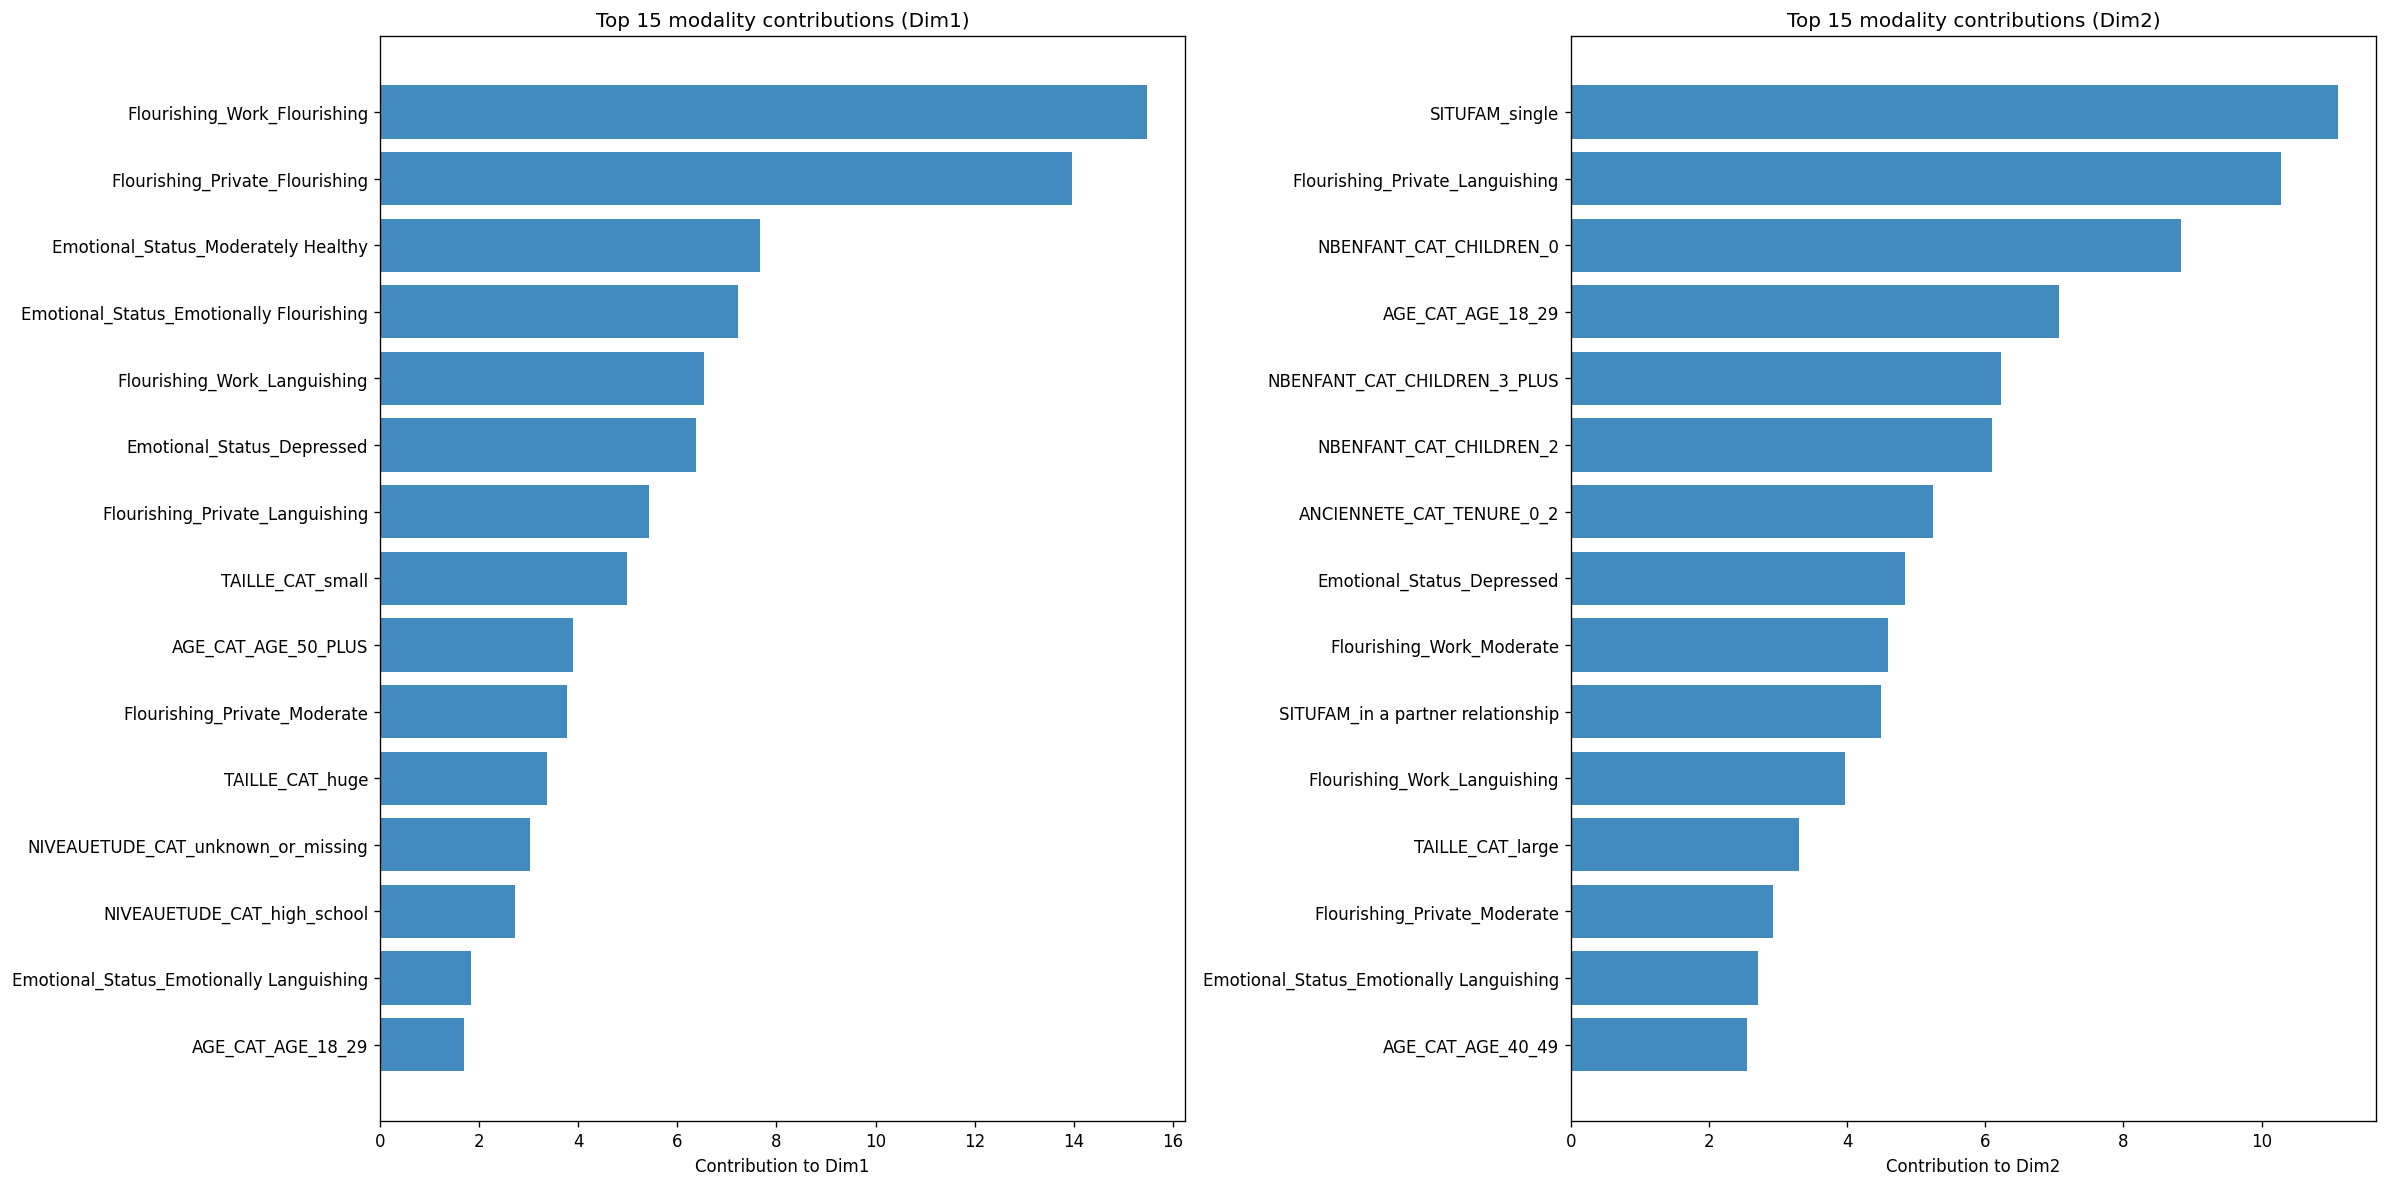

In [15]:
contrib_axis1 = pd.Series(acm.col_contrib_[:, 0], index=acm.col_labels_).sort_values(ascending=False)
contrib_axis2 = pd.Series(acm.col_contrib_[:, 1], index=acm.col_labels_).sort_values(ascending=False)
top_n = 15
plot_data_1 = contrib_axis1.head(top_n).sort_values(ascending=True)
plot_data_2 = contrib_axis2.head(top_n).sort_values(ascending=True)

fig, axs = plt.subplots(1, 2, figsize=(20, 10), dpi=120)
axs[0].barh(plot_data_1.index, plot_data_1.values, alpha=0.85)
axs[0].set_xlabel("Contribution to Dim1")
axs[0].set_title(f"Top {top_n} modality contributions (Dim1)")
axs[1].barh(plot_data_2.index, plot_data_2.values, alpha=0.85)
axs[1].set_xlabel("Contribution to Dim2")
axs[1].set_title(f"Top {top_n} modality contributions (Dim2)")
plt.tight_layout()
plt.show()

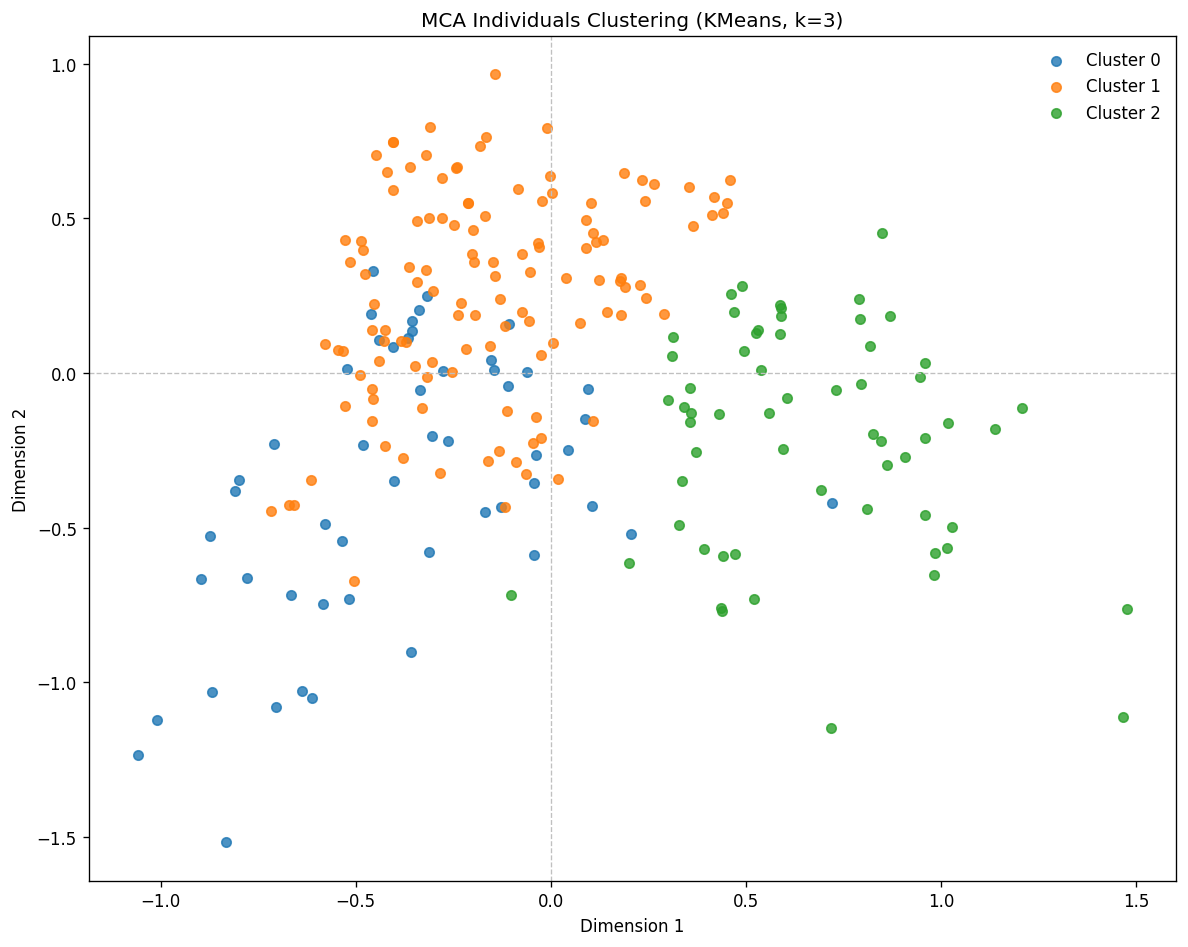

cluster
0     52
1    122
2     60
Name: count, dtype: int64


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ind_coords = pd.DataFrame(
    acm.row_coord_[:, :3],
    index=mca_ready.index,
    columns=["Dim1", "Dim2", "Dim3"]
)

X = StandardScaler().fit_transform(ind_coords)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X)

cluster_result = ind_coords.copy()
cluster_result["cluster"] = cluster_labels

plt.figure(figsize=(10, 8), dpi=120)
plt.axhline(0, color="silver", linestyle="--", linewidth=0.8)
plt.axvline(0, color="silver", linestyle="--", linewidth=0.8)

for c in sorted(cluster_result["cluster"].unique()):
    m = cluster_result["cluster"] == c
    plt.scatter(
        cluster_result.loc[m, "Dim1"],
        cluster_result.loc[m, "Dim2"],
        s=32, alpha=0.8, label=f"Cluster {c}"
    )

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title(f"MCA Individuals Clustering (KMeans, k=3)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print(cluster_result["cluster"].value_counts().sort_index())

In [17]:
profile_df = mca_ready.copy()
profile_df["cluster"] = cluster_result["cluster"]

print("Cluster size:")
print(profile_df["cluster"].value_counts().sort_index())

vars_to_profile = [
    "Flourishing_Work", "Flourishing_Private", "Emotional_Status",
    "SEX_CAT", "SITUFAM", "TAILLE_CAT", "NIVEAUETUDE_CAT",
    "AGE_CAT", "ANCIENNETE_CAT", "NBENFANT_CAT"
]

for v in vars_to_profile:
    print("\n" + "=" * 60)
    print(f"{v} by cluster (row %)")
    tab = pd.crosstab(profile_df["cluster"], profile_df[v], normalize="index") * 100
    print(tab.round(1))

Cluster size:
cluster
0     52
1    122
2     60
Name: count, dtype: int64

Flourishing_Work by cluster (row %)
Flourishing_Work  Flourishing  Languishing  Moderate
cluster                                             
0                         1.9         63.5      34.6
1                         4.1         13.9      82.0
2                        70.0          1.7      28.3

Flourishing_Private by cluster (row %)
Flourishing_Private  Flourishing  Languishing  Moderate
cluster                                                
0                            9.6         34.6      55.8
1                           17.2          0.0      82.8
2                           85.0          0.0      15.0

Emotional_Status by cluster (row %)
Emotional_Status  Depressed  Emotionally Flourishing  Emotionally Languishing  \
cluster                                                                         
0                      75.0                      1.9                     21.2   
1                      